# Lecture 4 — Class Exercise- Dennis Sebastian

# Scatter & Bubble Charts: Gapminder

In [8]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)
df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
df.head()

Loaded: 1704 rows


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [9]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

In [3]:
sorted(df["year"].unique())

[np.int64(1952),
 np.int64(1957),
 np.int64(1962),
 np.int64(1967),
 np.int64(1972),
 np.int64(1977),
 np.int64(1982),
 np.int64(1987),
 np.int64(1992),
 np.int64(1997),
 np.int64(2002),
 np.int64(2007)]

In [4]:
df['year'].value_counts()

year
1952    142
1957    142
1962    142
1967    142
1972    142
1977    142
1982    142
1987    142
1992    142
1997    142
2002    142
2007    142
Name: count, dtype: int64

# Task 1 — Scatter: life expectancy change over time


In [5]:
continent_choice = "Asia"   # change to Europe, Americas, Oceania if you want

df_cont = df.loc[df['continent'] == continent_choice]
df_cont = df_cont[df_cont['year'].isin([2000, 2007])]


# Scatter plot

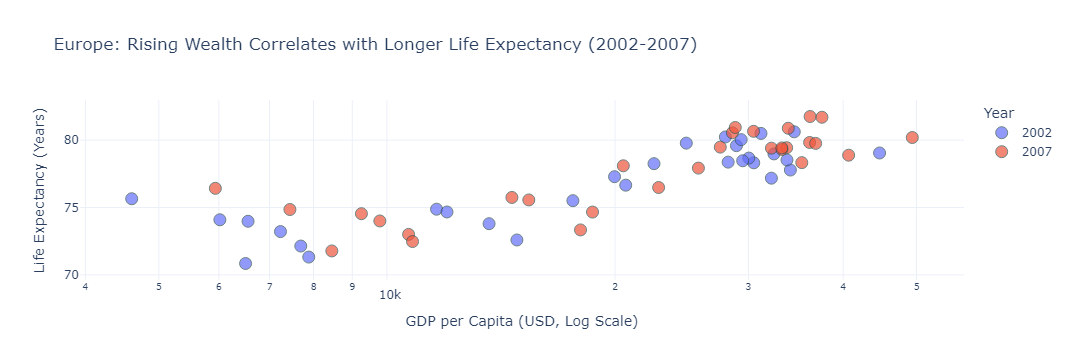

In [10]:
# Task 1: Scatter plot for Europe (2002 vs 2007)
# 1. Filter for Europe and the specific years
# Using .copy() here is the fix for the SettingWithCopyWarning
df_task1 = df[(df['continent'] == 'Europe') & (df['year'].isin([2002, 2007]))].copy()

# 2. Convert year to string so Plotly treats it as categorical (Rule 1)
df_task1['year'] = df_task1['year'].astype(str)

# 3. Create the chart
fig = px.scatter(
    df_task1, 
    x="gdpPercap", 
    y="lifeExp", 
    color="year",
    hover_name="country",
    log_x=True,           # Rule 4: Log scale for GDP
    template="plotly_white",
    title="Europe: Rising Wealth Correlates with Longer Life Expectancy (2002-2007)", # Rule 5: Insight title
    labels={
        "gdpPercap": "GDP per Capita (USD, Log Scale)",
        "lifeExp": "Life Expectancy (Years)",
        "year": "Year"
    }
)


fig.update_traces(marker=dict(size=12, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

# Task 2 — Bubble chart: tell a story

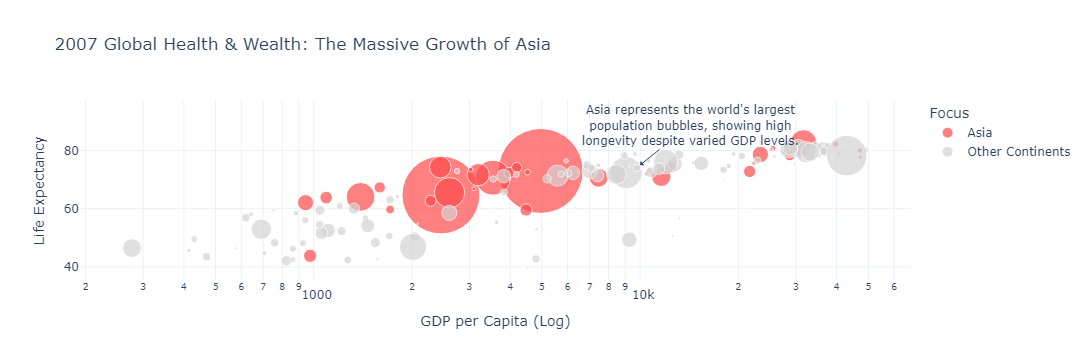

In [13]:
# 1. Filter for the full 2007 dataset
df_2007 = df[df['year'] == 2007].copy()

# 2. Create the 'highlight' logic (Highlighting Asia, greying others)
df_2007['highlight'] = df_2007['continent'].apply(lambda x: x if x == 'Asia' else 'Other Continents')

# 3. Define custom colors (Rule: one colour, all others grey)
color_map = {'Asia': '#FF4B4B', 'Other Continents': '#D3D3D3'}

# 4. Build the Bubble Chart
fig2 = px.scatter(
    df_2007, 
    x="gdpPercap", 
    y="lifeExp", 
    size="pop", 
    color="highlight",
    hover_name="country",
    color_discrete_map=color_map,
    log_x=True,             # Requirement: Log scale
    size_max=60,            # Requirement: Set size_max
    template="plotly_white",
    title="2007 Global Health & Wealth: The Massive Growth of Asia",
    labels={"gdpPercap": "GDP per Capita (Log)", "lifeExp": "Life Expectancy", "highlight": "Focus"}
)
    # 5. Add Annotation to tell the story
fig2.add_annotation(
    x=4.0, y=75, # Log position for Asia/China area
    xref="x", yref="y",
    text="Asia represents the world's largest<br>population bubbles, showing high<br>longevity despite varied GDP levels.",
    showarrow=True,
    arrowhead=1,
    ax=50, ay=-40
)

fig2.show()
